## Predicting Stellar Class - Exploratory Data Analysis
[Kaggle Playground Series - Season 6 Episode 6](https://www.kaggle.com/competitions/playground-series-s6e6/overview)

Notebook Author - Jona Nakai

In [1]:
from dotenv import load_dotenv
import kagglehub
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Load and Save Data

In [2]:
load_dotenv()

if not Path("Data/.complete/competitions/playground-series-s6e6/bundle.complete").is_file():
    kagglehub.competition_download("playground-series-s6e6", output_dir="Data")
    print("Data downloaded")
else:
    print("Data not downloaded, already exists")

Data not downloaded, already exists


In [3]:
data = pd.read_csv("Data/train.csv", index_col="id")
data.head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
id,,,,,,,,,,,
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  object 
dtypes: float64(8), object(3)
memory usage: 52.9+ MB


In [5]:
print(f'Rows: {data.shape[0]}')
print(f'Columns: {data.shape[1]}')

Rows: 577347
Columns: 11


In [ ]:
# no null values
data.isna().sum()

alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

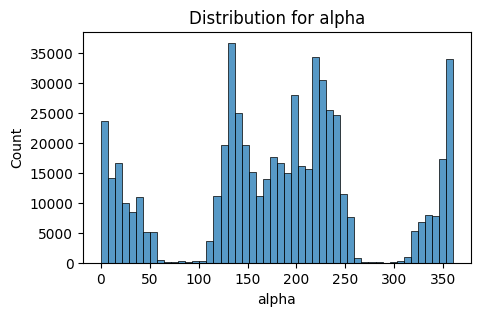

[alpha]
min: 0.0116837460479923
max: 359.999809770956
mean: 181.6166725014324



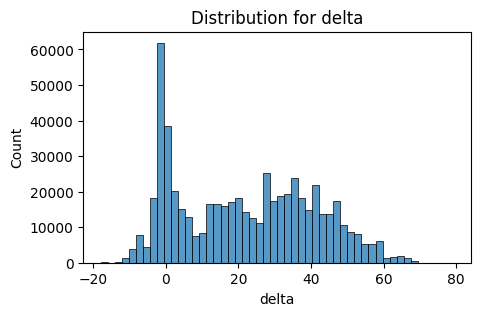

[delta]
min: -17.9669875155677
max: 79.158322400569
mean: 21.83465436901883



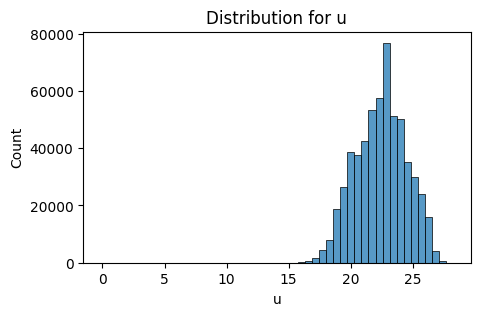

[u]
min: -0.1392249436681481
max: 28.253263322937897
mean: 22.441925526872602



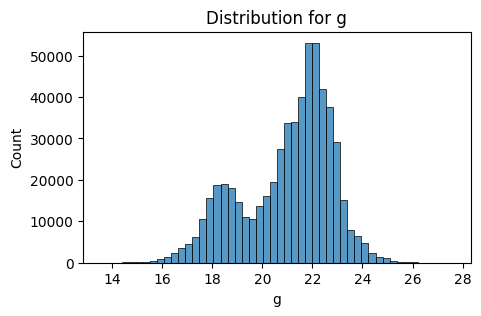

[g]
min: 13.535483058678922
max: 27.62020771336905
mean: 21.007273390353177



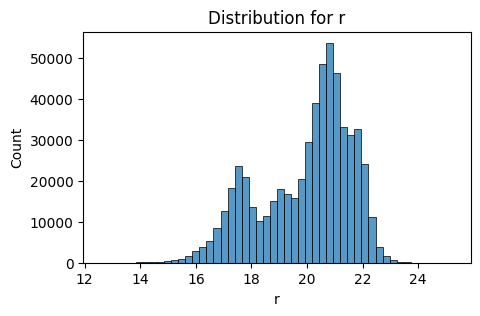

[r]
min: 12.57940713826054
max: 25.254499197443124
mean: 19.962810540029647



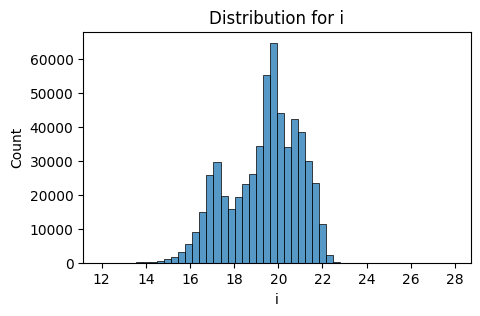

[i]
min: 11.962781454848429
max: 27.9108531624854
mean: 19.378910895517517



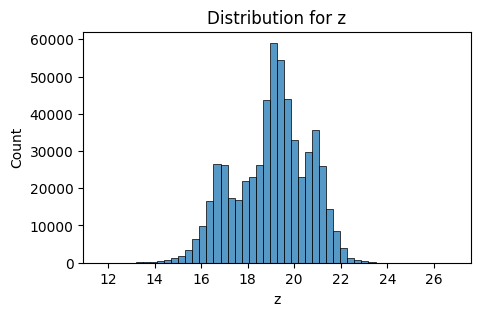

[z]
min: 11.68280337896474
max: 26.82686689523431
mean: 19.041135950117635



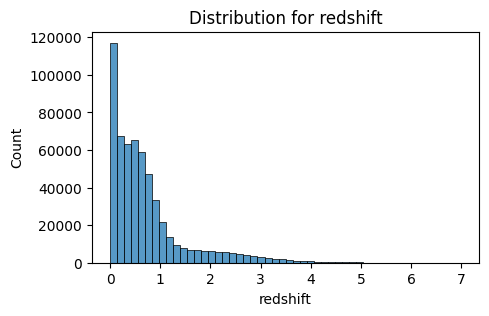

[redshift]
min: -0.0099703582110835
max: 7.010780492217193
mean: 0.7231354437546343



In [7]:
numerical_columns = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]

for col in numerical_columns:
    col_min = min(data[col])
    col_max = max(data[col])
    col_mean = sum(data[col]) / len(data[col])
    plt.figure(figsize=(5, 3))
    ax = sns.histplot(data[col], bins=50)
    ax.set(
        title=f'Distribution for {col}',
        xlabel=col,
        ylabel="Count"
    )
    plt.show()

    print(f'[{col}]')
    print(f'min: {col_min}')
    print(f'max: {col_max}')
    print(f'mean: {col_mean}')
    print()

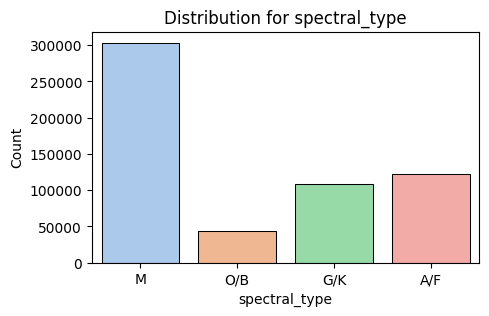

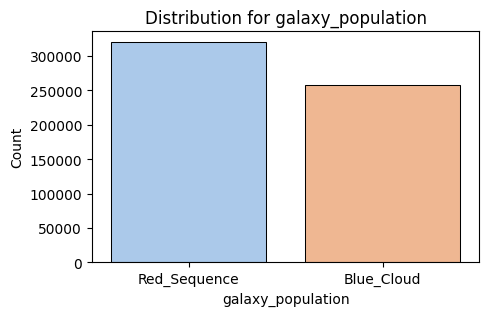

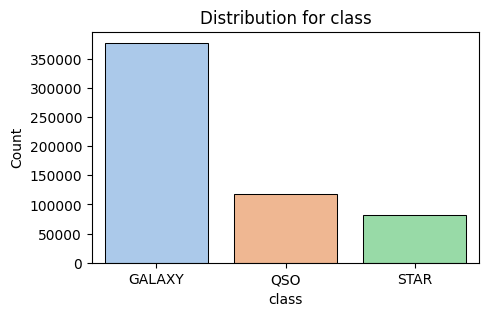

In [8]:
categorical_columns = ["spectral_type",	"galaxy_population", "class"]

for col in categorical_columns:
    plt.figure(figsize=(5, 3))
    ax = sns.countplot(
        data=data,
        x=col,
        hue=col,
        palette="pastel",
        edgecolor="black",
        linewidth=0.75
    )
    ax.set(
        title=f'Distribution for {col}',
        xlabel=col,
        ylabel="Count"
    )
    plt.show()

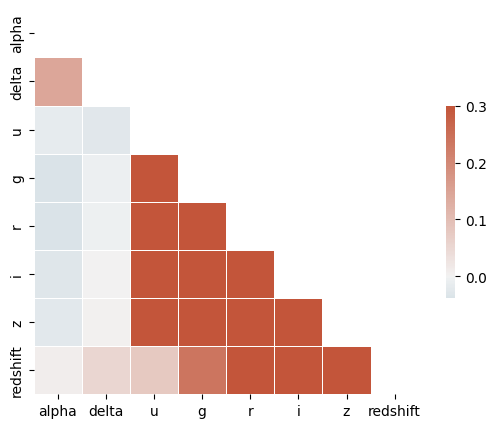

In [9]:
corr = data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(7, 5))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()